In [1]:
import os
import pandas as pd
from transformers import AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ----------------------------
# SETTINGS
# ----------------------------
RESOLUTIONS_CSV = "./ga_resolutions_1946_2019.csv"

# ----------------------------
# LOAD DATA
# ----------------------------
if not os.path.isfile(RESOLUTIONS_CSV):
    print(f"Error: File '{RESOLUTIONS_CSV}' does not exist.")
else:
    print("File found. Loading...")

    try:
        # Load in chunks to avoid memory issues
        chunksize = 2000
        chunks = []

        for chunk in pd.read_csv(RESOLUTIONS_CSV, chunksize=chunksize):
            chunks.append(chunk)

        df = pd.concat(chunks, ignore_index=True)
        print("CSV file loaded successfully.")

    except Exception as e:
        print(f"Error loading CSV file: {e}")

    finally:
        pass

documents = df['content']

/Users/david-macbook/Documents/UZH_WORK/Thesis/United_Nations_citation_explorer/myenv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/david-macbook/Documents/UZH_WORK/Thesis/United_Nations_citation_explorer/myenv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade

File found. Loading...
CSV file loaded successfully.


In [4]:
# Load Qwen3 tokenizer
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen3-8B")

# Compute token counts
token_counts = [
    len(tokenizer.encode(doc, add_special_tokens=False))
    for doc in documents
]

# Number of truncated documents
max_tokens = [3000, 4500, 6000]
n_truncated = []
for max_token in max_tokens:
    n_truncated.append(sum(x > max_token for x in token_counts))



TypeError: 'int' object is not iterable

For 3000 tokens we have 1780 truncated tokens.
Percentage truncated: 9.94%

For 4500 tokens we have 803 truncated tokens.
Percentage truncated: 4.48%

For 6000 tokens we have 439 truncated tokens.
Percentage truncated: 2.45%



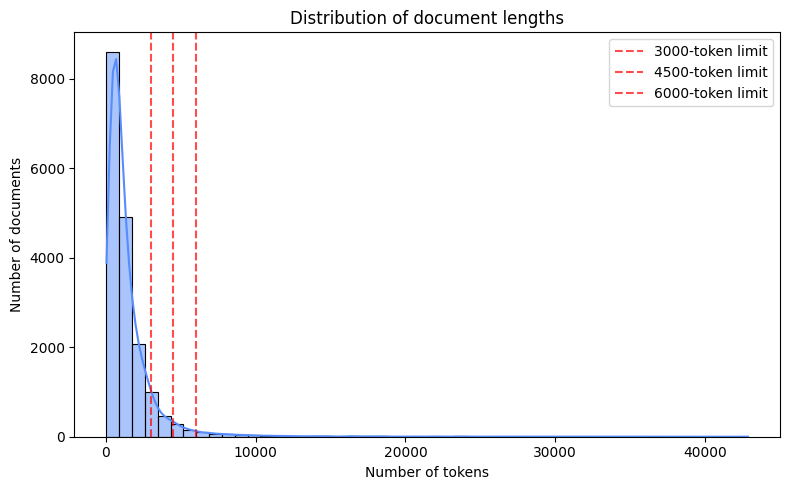

In [7]:
for max, n in zip(max_tokens, n_truncated):
    print(f"For {max} tokens we have {n} truncated tokens.")
    print(f"Percentage truncated: {100*n/len(documents):.2f}%\n")

# Plot histogram
plt.figure(figsize=(8,5))

sns.histplot(
    token_counts,
    bins=50,
    kde=True
)

for max_token in max_tokens:
    plt.axvline(
        max_token,
        color="red",
        linestyle="--",
        label=f"{max_token}-token limit",
        alpha=0.7
    )

plt.xlabel("Number of tokens")
plt.ylabel("Number of documents")
plt.title("Distribution of document lengths")
plt.legend()

plt.tight_layout()
plt.show()

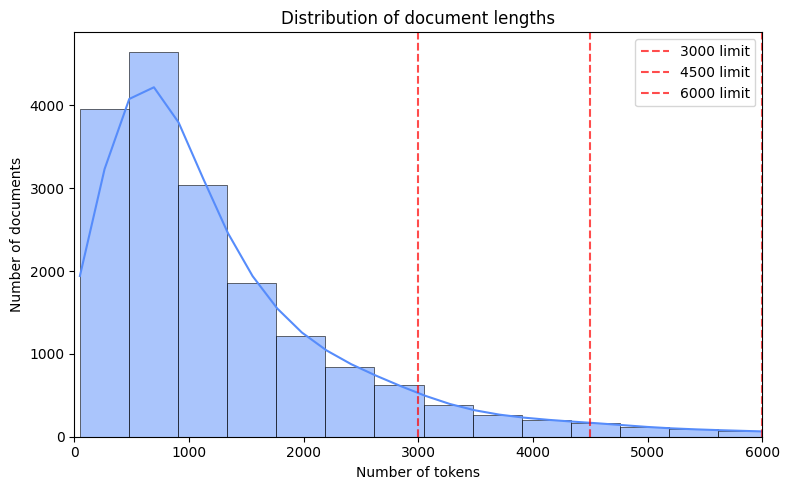

In [14]:
# Plot histogram
plt.figure(figsize=(8,5))

sns.histplot(
    token_counts,
    bins=100,
    kde=True
)

for max_token in max_tokens:
    plt.axvline(
        max_token,
        color="red",
        linestyle="--",
        label=f"{max_token} limit",
        alpha=0.7
    )
plt.xlim(0, 6000)

plt.xlabel("Number of tokens")
plt.ylabel("Number of documents")
plt.title("Distribution of document lengths")
plt.legend()

plt.tight_layout()
plt.show()

## Prescindimos del 10% ?
3000 tokens ya son bastantes, de hecho quizas se puedan entrenar mejor los modelos para que tambien remitan los SC resolutions.

Para conseguir los temas y los verbos quizas si es mejor trocear las resoluciones en una pequeña ventana y preguntar un modelo instruct si la resolucion esta precedida por un verbo en concreto
